# Topic 2.A — Classical Shadows with Randomized Pauli Measurements

**Goal:** Implement classical shadows using randomized Pauli measurements to estimate
second R&#233;nyi entropies $S_2(\rho_A) = -\log_2 \mathrm{Tr}(\rho_A^2)$ of subsystems of the
time-evolved N&#233;el state under the XY-Hamiltonian.

**Reference:** [arXiv:2203.11374](https://arxiv.org/abs/2203.11374), Section II.D — *Estimating purities and R&#233;nyi entropy*

In [1]:
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt

np.random.seed(42)

N_QUBITS = 10
N_TROTTER_STEPS = 20

## 1. N&#233;el State and XY-Hamiltonian Time Evolution

**N&#233;el state:** $|\psi\rangle = |1010101010\rangle$

**XY-Hamiltonian** (nearest-neighbor, open boundary conditions, $J = 1$):

$$H_{XY} = \sum_{i=0}^{N-2} \frac{X_i X_{i+1} + Y_i Y_{i+1}}{2}$$

**Identity (proved in report):** $\sigma_i^+\sigma_j^- + \mathrm{h.c.} = \frac{X_iX_j + Y_iY_j}{2}$

**First-order Trotter decomposition:**

$$e^{-iH_{XY}t} \approx \left(\prod_{i=0}^{N-2} e^{-i\delta t\,X_iX_{i+1}/2}\;e^{-i\delta t\,Y_iY_{i+1}/2}\right)^{n_\mathrm{steps}}, \qquad \delta t = t / n_\mathrm{steps}$$

In PennyLane, `qml.IsingXX(phi, wires)` implements $e^{-i(\phi/2)\,X \otimes X}$ and analogously `qml.IsingYY`.

In [2]:
dev = qml.device("default.qubit", wires=N_QUBITS)


def neel_state():
    """Prepare the Neel state |1010101010>."""
    for i in range(0, N_QUBITS, 2):
        qml.PauliX(wires=i)


def trotter_step(dt):
    """Single first-order Trotter step for H_XY."""
    for i in range(N_QUBITS - 1):
        qml.IsingXX(dt, wires=[i, i + 1])
        qml.IsingYY(dt, wires=[i, i + 1])


def time_evolution(t, n_steps):
    """Trotterized time evolution exp(-i H_XY t)."""
    dt = t / n_steps
    for _ in range(n_steps):
        trotter_step(dt)


@qml.qnode(dev)
def get_statevector(t, n_steps=N_TROTTER_STEPS):
    neel_state()
    if t > 0:
        time_evolution(t, n_steps)
    return qml.state()


# Verify: Neel state at t = 0
sv0 = np.array(get_statevector(0.0))
neel_idx = int("1010101010", 2)
print(f"Neel state index: {neel_idx}")
print(f"Amplitude at Neel index: {np.abs(sv0[neel_idx]):.6f}")
print(f"State norm: {np.linalg.norm(sv0):.6f}")

Neel state index: 682
Amplitude at Neel index: 1.000000
State norm: 1.000000


## 2. Exact Second R&#233;nyi Entropy (State-Vector Simulation)

For a pure state $|\psi\rangle$ and subsystem $A = \{0, 1, \ldots, i{-}1\}$:

$$\rho_A = \mathrm{Tr}_B\!\bigl(|\psi\rangle\!\langle\psi|\bigr), \qquad S_2(\rho_A) = -\log_2 \mathrm{Tr}(\rho_A^2)$$

The x-axis corresponds to subsystems $A = [1 \to i]$ as in Fig.&nbsp;3b of the paper.

t = 0.0:  max S_2 = -0.0000
t = 0.2:  max S_2 = 0.1124
t = 0.4:  max S_2 = 0.4094
t = 0.6:  max S_2 = 0.7564
t = 0.8:  max S_2 = 0.9669
t = 1.0:  max S_2 = 1.1912


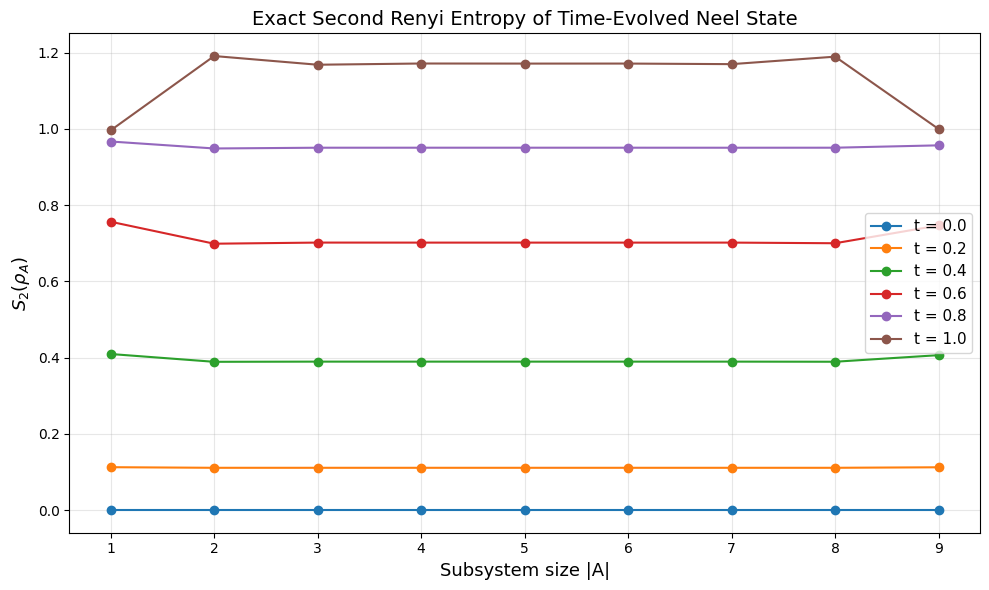

In [3]:
def exact_renyi_entropies(statevector, n_qubits):
    """Compute exact S_2(rho_A) for subsystems A = [0,...,i-1], i = 1,...,n-1."""
    entropies = []
    for n_a in range(1, n_qubits):
        n_b = n_qubits - n_a
        psi = statevector.reshape(2**n_a, 2**n_b)
        rho_a = psi @ psi.conj().T
        purity = np.real(np.trace(rho_a @ rho_a))
        entropies.append(-np.log2(max(purity, 1e-15)))
    return np.array(entropies)


# Compute exact entropies for several time points
t_values = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
exact_results = {}

for t in t_values:
    sv = np.array(get_statevector(t))
    exact_results[t] = exact_renyi_entropies(sv, N_QUBITS)
    print(f"t = {t:.1f}:  max S_2 = {exact_results[t].max():.4f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
subsystem_sizes = np.arange(1, N_QUBITS)

for t in t_values:
    ax.plot(subsystem_sizes, exact_results[t], "o-", label=f"t = {t:.1f}")

ax.set_xlabel("Subsystem size |A|", fontsize=13)
ax.set_ylabel(r"$S_2(\rho_A)$", fontsize=13)
ax.set_title("Exact Second Renyi Entropy of Time-Evolved Neel State", fontsize=14)
ax.legend(fontsize=11)
ax.set_xticks(subsystem_sizes)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Random Pauli Measurements (Data Acquisition Phase)

For each of $M$ measurement rounds:
1. Choose a random Pauli basis $P_i \in \{X, Y, Z\}$ **independently** for each qubit $i$.
2. Rotate each qubit from the Pauli eigenbasis to the computational (Z) basis.
3. Measure $K$ shots in the computational basis.
4. **Store** the basis choices $(P_1, \ldots, P_n)$ and the $K$ bitstring outcomes.

| Pauli basis | Gate applied before Z-measurement |
|:-----------:|:---------------------------------:|
| $X$         | Hadamard $H$                      |
| $Y$         | $H S^\dagger$                     |
| $Z$         | Identity $I$                      |

In [4]:
# Single-qubit rotation matrices: Pauli eigenbasis -> Z-basis
H_gate = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
Sdg = np.array([[1, 0], [0, -1j]], dtype=complex)
ROTATIONS = {0: H_gate, 1: H_gate @ Sdg, 2: np.eye(2, dtype=complex)}


def apply_single_qubit_gate(state, gate, qubit, n_qubits):
    """Apply a single-qubit gate to qubit `qubit` in the statevector."""
    state = state.reshape([2] * n_qubits)
    state = np.tensordot(gate, state, axes=([1], [qubit]))
    state = np.moveaxis(state, 0, qubit)
    return state.reshape(2**n_qubits)


def random_pauli_measurements(statevector, M, K, n_qubits):
    """
    Simulate M random Pauli measurement settings, each with K shots.

    Returns
    -------
    bases : ndarray, shape (M, n_qubits)
        Pauli basis choice per qubit (0=X, 1=Y, 2=Z).
    outcomes : ndarray, shape (M, K, n_qubits)
        Measurement outcomes (0 or 1) for each shot.
    """
    n = n_qubits
    bases = np.random.randint(0, 3, size=(M, n))
    outcomes = np.zeros((M, K, n), dtype=np.int8)

    for m in range(M):
        # Apply per-qubit basis rotations
        rotated = statevector.copy()
        for i in range(n):
            if bases[m, i] != 2:  # skip identity for Z-basis
                rotated = apply_single_qubit_gate(
                    rotated, ROTATIONS[bases[m, i]], i, n
                )

        # Sample K measurement outcomes from Born probabilities
        probs = np.abs(rotated) ** 2
        probs /= probs.sum()  # numerical stability
        samples = np.random.choice(2**n, size=K, p=probs)

        # Extract per-qubit bits (qubit 0 = MSB)
        for i in range(n):
            outcomes[m, :, i] = (samples >> (n - 1 - i)) & 1

    return bases, outcomes


print("Random Pauli measurement functions defined.")

Random Pauli measurement functions defined.


## 4. R&#233;nyi Entropy Estimation from Classical Shadows

Using the **cross-correlator estimator** (Eq.&nbsp;(3) in the paper):

$$\mathrm{Tr}(\rho_A^2) \;=\; \mathbb{E}_U\!\left[\frac{2}{K(K{-}1)}\sum_{k<k'}\;\prod_{i \in A}\bigl(3\,\delta_{b_i^{(k)},\,b_i^{(k')}} - 1\bigr)\right]$$

where $b_i^{(k)}$ is the outcome of qubit $i$ in shot $k$ under random measurement setting $U$.

**Single-qubit derivation:** For random $P \in \{X,Y,Z\}$ and two independent
samples $b, b'$ from measuring $\rho$ in basis $P$:

$$\mathbb{E}_P\bigl[3\,\delta_{b,b'} - 1\bigr] = \mathrm{Tr}(\rho^2)$$

The multi-qubit formula follows from the tensor-product structure of the measurement.

Then: $S_2(\rho_A) = -\log_2 \mathrm{Tr}(\rho_A^2)$

In [5]:
def shadow_purity(outcomes, subsystem_size):
    """
    Estimate Tr(rho_A^2) using the cross-correlator over pairs of shots
    within each random measurement setting.
    """
    M, K, n = outcomes.shape
    n_a = subsystem_size
    sub = outcomes[:, :, :n_a]  # restrict to subsystem A

    # Upper-triangular mask for distinct pairs (k < k')
    mask = np.triu(np.ones((K, K), dtype=bool), k=1)
    n_pairs = mask.sum()

    purity_sum = 0.0
    for m in range(M):
        # Pairwise match indicator: (K, K, n_a)
        matches = (sub[m, :, None, :] == sub[m, None, :, :])
        # Cross-correlator factor: 3*delta - 1 per qubit, product over subsystem
        factors = 3.0 * matches.astype(np.float64) - 1.0
        products = np.prod(factors, axis=2)  # (K, K)
        purity_sum += products[mask].sum() / n_pairs

    return purity_sum / M


def shadow_renyi_entropies(outcomes, n_qubits):
    """Compute shadow-estimated S_2 for all subsystems A = [0,...,i-1]."""
    entropies = []
    for n_a in range(1, n_qubits):
        pur = shadow_purity(outcomes, n_a)
        if pur > 0:
            entropies.append(max(0.0, -np.log2(pur)))
        else:
            entropies.append(np.nan)
    return np.array(entropies)


print("Shadow estimator functions defined.")

Shadow estimator functions defined.


## 5. Comparison: Exact vs Classical Shadow R&#233;nyi Entropies

We compute classical shadows for each time $t \in [0, 1]$ and compare the
estimated $S_2(\rho_A)$ against the exact state-vector result.

t = 0.00 done
t = 0.20 done
t = 0.40 done
t = 0.60 done
t = 0.80 done
t = 1.00 done


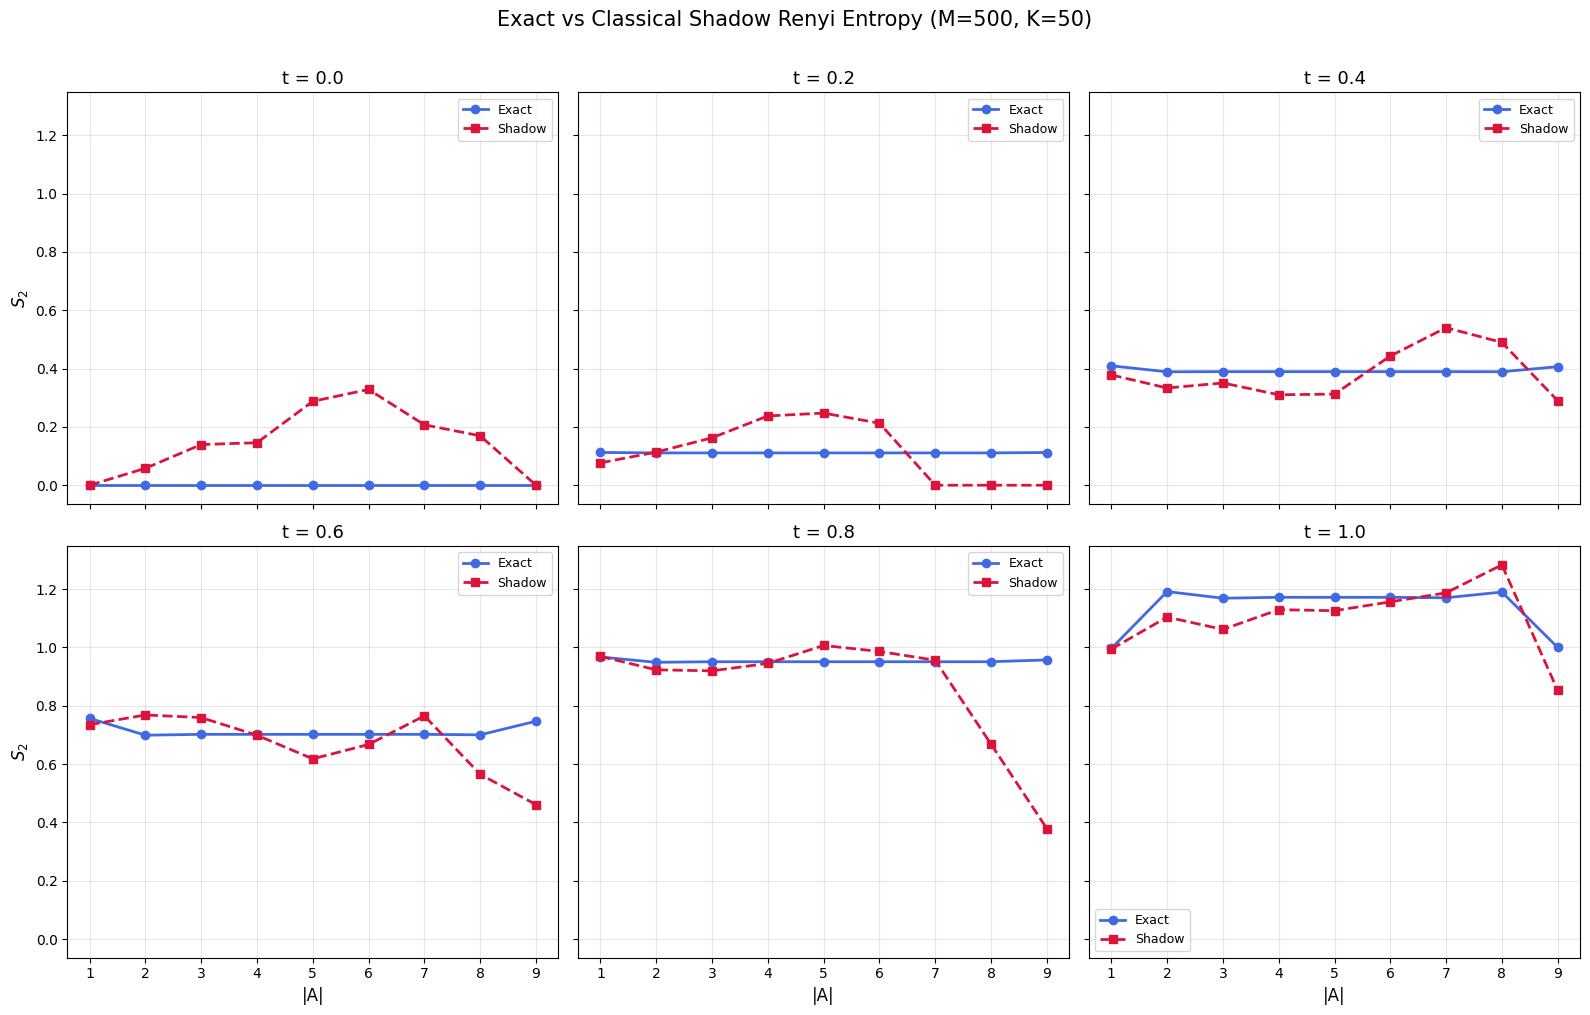

In [6]:
M = 500   # number of random measurement settings
K = 50    # shots per setting

shadow_results = {}

for t in t_values:
    sv = np.array(get_statevector(t))
    _, outcomes = random_pauli_measurements(sv, M, K, N_QUBITS)
    shadow_results[t] = shadow_renyi_entropies(outcomes, N_QUBITS)
    print(f"t = {t:.2f} done")

# --- Panel comparison plot ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
subsystem_sizes = np.arange(1, N_QUBITS)

for idx, t in enumerate(t_values):
    ax = axes.flat[idx]
    ax.plot(subsystem_sizes, exact_results[t], "o-", color="royalblue",
            linewidth=2, markersize=6, label="Exact")
    ax.plot(subsystem_sizes, shadow_results[t], "s--", color="crimson",
            linewidth=2, markersize=6, label="Shadow")
    ax.set_title(f"t = {t:.1f}", fontsize=13)
    if idx >= 3:
        ax.set_xlabel("|A|", fontsize=12)
    if idx % 3 == 0:
        ax.set_ylabel(r"$S_2$", fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xticks(subsystem_sizes)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f"Exact vs Classical Shadow Renyi Entropy (M={M}, K={K})",
    fontsize=15, y=1.01,
)
plt.tight_layout()
plt.show()

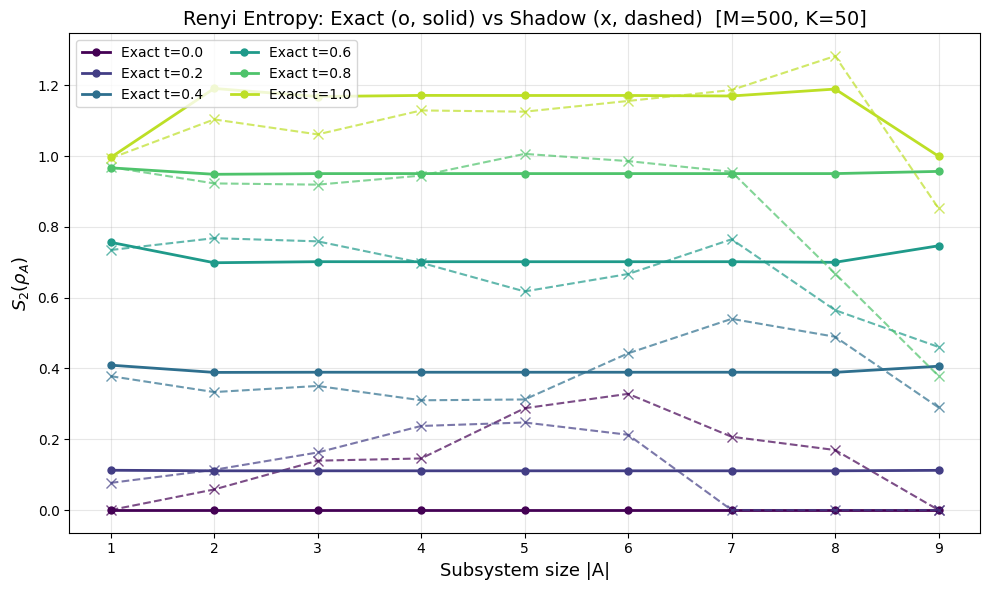

In [7]:
# Combined overlay plot (analogous to Fig. 3b in the paper)
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.cm.viridis
colors = [cmap(x) for x in np.linspace(0.0, 0.9, len(t_values))]

for idx, t in enumerate(t_values):
    ax.plot(subsystem_sizes, exact_results[t], "o-", color=colors[idx],
            linewidth=2, markersize=5, label=f"Exact t={t:.1f}")
    ax.plot(subsystem_sizes, shadow_results[t], "x--", color=colors[idx],
            linewidth=1.5, markersize=7, alpha=0.7)

ax.set_xlabel("Subsystem size |A|", fontsize=13)
ax.set_ylabel(r"$S_2(\rho_A)$", fontsize=13)
ax.set_title(
    f"Renyi Entropy: Exact (o, solid) vs Shadow (x, dashed)  [M={M}, K={K}]",
    fontsize=14,
)
ax.legend(fontsize=10, ncol=2)
ax.set_xticks(subsystem_sizes)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Dependence on $M$ and $K$ (For 8+)

We investigate how the accuracy of the shadow estimator depends on:
- $M$ — number of random measurement settings (basis diversity)
- $K$ — number of shots per setting (cross-correlator pair statistics)

We fix $t = 0.5$ and subsystem size $|A| = 5$ and repeat each configuration
10 times to estimate mean and standard deviation.

> **Note:** This cell may take a few minutes to run.

In [8]:
t_test = 0.5
sv_test = np.array(get_statevector(t_test))
exact_s2_all = exact_renyi_entropies(sv_test, N_QUBITS)
target_sub = 5
exact_target = exact_s2_all[target_sub - 1]
print(f"Exact S_2 at |A|={target_sub}, t={t_test}: {exact_target:.4f}")

n_repeats = 10

# --- Vary M with K fixed ---
K_fixed = 50
M_values = [50, 100, 200, 500, 1000]
m_estimates = {m: [] for m in M_values}

print("\nVarying M (K={} fixed):".format(K_fixed))
for m_val in M_values:
    for _ in range(n_repeats):
        _, out = random_pauli_measurements(sv_test, m_val, K_fixed, N_QUBITS)
        pur = shadow_purity(out, target_sub)
        s2 = max(0.0, -np.log2(max(pur, 1e-15)))
        m_estimates[m_val].append(s2)
    mu, sigma = np.mean(m_estimates[m_val]), np.std(m_estimates[m_val])
    print(f"  M = {m_val:5d}:  S_2 = {mu:.4f} +/- {sigma:.4f}")

# --- Vary K with M fixed ---
M_fixed = 500
K_values = [2, 5, 10, 20, 50, 100]
k_estimates = {k: [] for k in K_values}

print(f"\nVarying K (M={M_fixed} fixed):")
for k_val in K_values:
    for _ in range(n_repeats):
        _, out = random_pauli_measurements(sv_test, M_fixed, k_val, N_QUBITS)
        pur = shadow_purity(out, target_sub)
        s2 = max(0.0, -np.log2(max(pur, 1e-15)))
        k_estimates[k_val].append(s2)
    mu, sigma = np.mean(k_estimates[k_val]), np.std(k_estimates[k_val])
    print(f"  K = {k_val:5d}:  S_2 = {mu:.4f} +/- {sigma:.4f}")

Exact S_2 at |A|=5, t=0.5: 0.5502

Varying M (K=50 fixed):
  M =    50:  S_2 = 0.5702 +/- 0.2756
  M =   100:  S_2 = 0.5436 +/- 0.1910
  M =   200:  S_2 = 0.6313 +/- 0.1744
  M =   500:  S_2 = 0.5519 +/- 0.0881
  M =  1000:  S_2 = 0.5474 +/- 0.0439

Varying K (M=500 fixed):
  K =     2:  S_2 = 0.3463 +/- 0.3396
  K =     5:  S_2 = 0.8259 +/- 0.7662
  K =    10:  S_2 = 0.6035 +/- 0.1838
  K =    20:  S_2 = 0.4917 +/- 0.1119
  K =    50:  S_2 = 0.5610 +/- 0.0551
  K =   100:  S_2 = 0.6118 +/- 0.0651


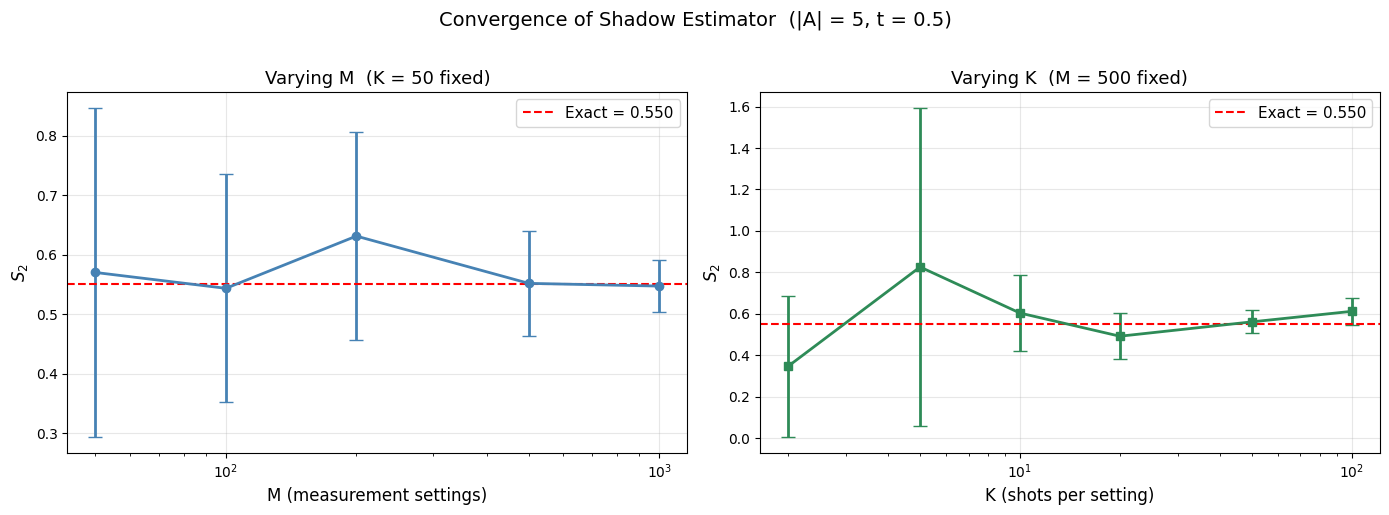

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: vary M ---
means_m = [np.mean(m_estimates[m]) for m in M_values]
stds_m  = [np.std(m_estimates[m])  for m in M_values]
ax1.errorbar(M_values, means_m, yerr=stds_m,
             fmt="o-", capsize=5, color="steelblue", linewidth=2)
ax1.axhline(exact_target, color="red", ls="--", lw=1.5,
            label=f"Exact = {exact_target:.3f}")
ax1.set_xlabel("M (measurement settings)", fontsize=12)
ax1.set_ylabel(r"$S_2$", fontsize=12)
ax1.set_title(f"Varying M  (K = {K_fixed} fixed)", fontsize=13)
ax1.set_xscale("log")
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# --- Right: vary K ---
means_k = [np.mean(k_estimates[k]) for k in K_values]
stds_k  = [np.std(k_estimates[k])  for k in K_values]
ax2.errorbar(K_values, means_k, yerr=stds_k,
             fmt="s-", capsize=5, color="seagreen", linewidth=2)
ax2.axhline(exact_target, color="red", ls="--", lw=1.5,
            label=f"Exact = {exact_target:.3f}")
ax2.set_xlabel("K (shots per setting)", fontsize=12)
ax2.set_ylabel(r"$S_2$", fontsize=12)
ax2.set_title(f"Varying K  (M = {M_fixed} fixed)", fontsize=13)
ax2.set_xscale("log")
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle(
    f"Convergence of Shadow Estimator  (|A| = {target_sub}, t = {t_test})",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()

K = 2 row done
K = 5 row done
K = 10 row done
K = 20 row done
K = 50 row done


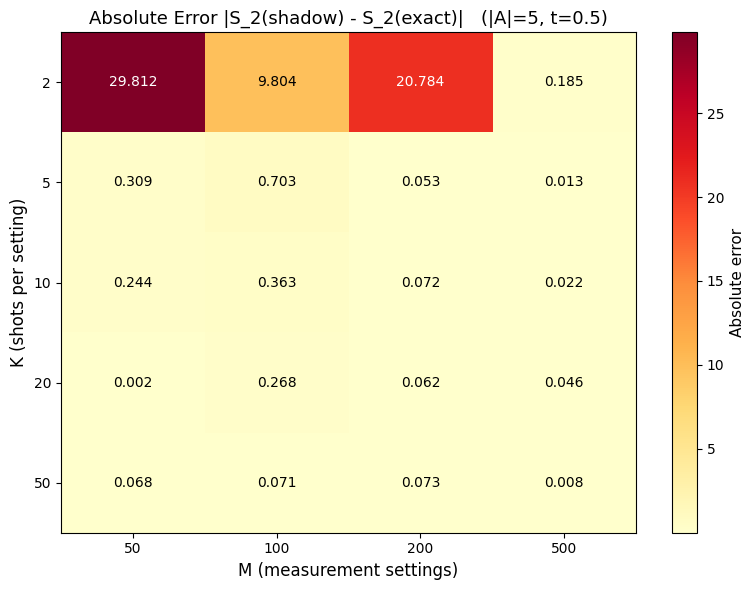

In [10]:
# Heatmap: absolute error as a function of both M and K
M_sweep = [50, 100, 200, 500]
K_sweep = [2, 5, 10, 20, 50]
n_reps = 5

error_grid = np.zeros((len(K_sweep), len(M_sweep)))

for i, kv in enumerate(K_sweep):
    for j, mv in enumerate(M_sweep):
        ests = []
        for _ in range(n_reps):
            _, out = random_pauli_measurements(sv_test, mv, kv, N_QUBITS)
            pur = shadow_purity(out, target_sub)
            ests.append(max(0.0, -np.log2(max(pur, 1e-15))))
        error_grid[i, j] = abs(np.mean(ests) - exact_target)
    print(f"K = {kv} row done")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(error_grid, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(M_sweep)))
ax.set_xticklabels(M_sweep)
ax.set_yticks(range(len(K_sweep)))
ax.set_yticklabels(K_sweep)
ax.set_xlabel("M (measurement settings)", fontsize=12)
ax.set_ylabel("K (shots per setting)", fontsize=12)
ax.set_title(
    f"Absolute Error |S_2(shadow) - S_2(exact)|   (|A|={target_sub}, t={t_test})",
    fontsize=13,
)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Absolute error", fontsize=11)

for i in range(len(K_sweep)):
    for j in range(len(M_sweep)):
        txt_color = "white" if error_grid[i, j] > 0.5 * error_grid.max() else "black"
        ax.text(j, i, f"{error_grid[i, j]:.3f}",
                ha="center", va="center", color=txt_color, fontsize=10)

plt.tight_layout()
plt.show()

## Summary

1. **Exact R&#233;nyi entropies** show increasing entanglement as the N&#233;el state evolves
   under $H_{XY}$, with a characteristic "dome" shape peaking near the chain center.

2. **Classical shadows** with randomized Pauli measurements successfully recover the
   exact second R&#233;nyi entropies with reasonable accuracy using $M = 500$ settings
   and $K = 50$ shots per setting.

3. **Parameter dependence:**
   - Increasing $M$ (measurement settings) reduces variance from basis sampling.
   - Increasing $K$ (shots per setting) improves the cross-correlator estimate.
   - Both contribute to the total measurement budget $M \times K$.
   - For larger subsystems $|A|$, more measurements are needed because the
     estimator variance grows exponentially with $|A|$.